In [21]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches



In [26]:
#中间QAH

#矩阵信息 
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m+4*B/(a**2))*sz

def h_x(B,a,A, Bz, yweizhi):
    return ((-B/(a**2))*sz-(1j/2)*A*sx)*np.exp((2*np.pi*1j*a**2)*Bz*yweizhi)

def h_y(B,a,A):
    return (-B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A, Bz, yweizhi):
    TX_block=h_x(B,a,A, Bz, yweizhi)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    xshumu,Nd,    A,  Bz, yweizhi):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < xshumu-1:
            H[i][i+1] = t_x(B,a,A, Bz, yweizhi)

        if i > 0:
            H[i][i-1] = t_x(B,a,A, Bz, yweizhi).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   xshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i]=t_y(B,a,A)

    #
    H = np.block(H)
    return H

m=-0.5       #0.5对应。。
A=1
B=0.5       #-1对应。。
Bz=0.005
Ex=0         #0.005/10对应。。

delta=0#0.75
chaodaojiao=0
#T_Tc=1e-4
Delta = delta#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))
#KBT=2 * delta * T_Tc / 3.5
#shumu=401

a=1
yshumu=10
xshumu=10
yweizhi=1

uS=0

uS_set=[]
for i in range(xshumu):
    uS_set.append(uS - Ex *1* (i - xshumu/2))
#print(uN_set[99])
#print(uS_set[99])


H_q= H_onstie(m,B,a   ,uS_set,Delta,0,    xshumu,4,    A, Bz, yweizhi)
T_21= H_hop(B,a,A,   xshumu,4)#.conj().T


H_q_list = []
for i in range(yshumu):
    # 这里的 i 就是 yweizhi
    H_q_i = H_onstie(m, B, a, uS_set, Delta,0,    xshumu, 4, A, Bz, i)
    H_q_list.append(H_q_i)
#T_LD=H_hop(B,a,A,  xshumu,4).conj().T
#T_RD=H_hop(B,a,A,   xshumu,4)


if m**2<delta**2+uS**2:
    leiN=1
elif m<-(delta**2+uS**2)**0.5:
    leiN=2
elif m>(delta**2+uS**2)**0.5:
    leiN=0


params_str = f"leiN={leiN}_m={m}_A={A}_B={B}_del={delta}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')
save_dir = rf"D:\结果\2026.4.18下"
os.makedirs(save_dir, exist_ok=True)
def save_fig_by_title_1(name):

    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')


    filename = os.path.join(save_dir, safe_name + ".png")


    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")

save = True  



Calculating Bands: 100%|██████████| 601/601 [00:00<00:00, 10056.84it/s]


已保存图片: D:\结果\2026.4.18下\leiN=2_m=-0.5_A=1_B=0.5_del=0_x=10_uS=0_Ex=0_Bz=0.005.png
2


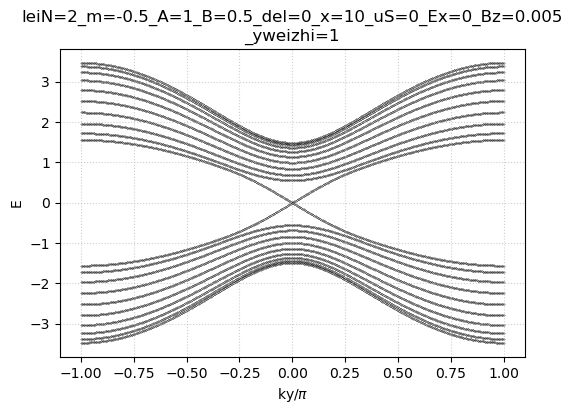

In [27]:
# 中间能带
ks1 = np.linspace(-1*np.pi, 1*np.pi,601)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T.conj().T * np.exp(-1j * k) + T * np.exp(1j * k)

energies1 = []

for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_q, T_21)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 4))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.01)
#plt.ylim(-1.5,1.5)
#plt.xlim(-0.5,0.5)
#plt.ylim(-0.5,0.5)
#plt.xlim(-0.2,0.2)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
plt.title(f'{params_str}'+'\n'+f'_yweizhi={yweizhi}')
plt.grid(True, linestyle=':', alpha=0.6)
save_fig_by_title_1(params_str)
print(leiN)
plt.show()

In [ ]:
#本征态
k_target = 0.01*np.pi
# 计算 k 时的哈密顿量
H_k0 = Hk(k_target, H_q, T_21)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from tqdm import tqdm

# (这里假设前面的 m, A, B, delta, xshumu, uS, Ex, Bz, leiN, k_target, H_k0 都已经定义好)

param_folder = f"leiN={leiN}_k={k_target:.4f}_m={m}_A={A}_B={B}_del={delta}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
save_dir = rf"D:\结果\2026.4.18\{param_folder}"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 求解本征值和本征态
evals, evecs = np.linalg.eigh(H_k0)

Nd = 4  # 你代码里定义的每个格点的自由度维度
print(f"\n开始计算 k={k_target} 的本征态波函数...")
print(f"共 {len(evals)} 个态，正在保存至 {save_dir} ...")

# 1. 构造单个格点的 sz 算符
sz_local = np.array([1, -1, 1, -1])  # 对应 (e↑, e↓, h↑, h↓) 的自旋/轨道极化权重

# 2. 扩展成整个波函数长度的极化权重向量 (长度为 Nd * xshumu)
Sz_weights = np.tile(sz_local, xshumu)

for i in tqdm(range(len(evals)), desc="Saving Wavefunctions"):
    E = evals[i]
    psi = evecs[:, i] 
    
    # ---------------- 核心修改：计算 Sz 期望值 ----------------
    # 期望值 <psi| Sz |psi> = sum( |psi_j|^2 * Sz_weights_j )
    prob = np.abs(psi)**2
    # 为了避免因为数值精度导致的归一化问题，先归一化波函数概率
    prob = prob / np.sum(prob) 
    
    # 计算极化期望值
    sz_exp = np.sum(prob * Sz_weights)
    # --------------------------------------------------------
    
    # 画图：
    plt.figure(figsize=(10, 5))
    
    # 定义 4 种颜色：红(e↑), 蓝(e↓), 绿(h↑), 橙(h↓)
    color_map = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e'] 
    
    # 循环生成 柱子的颜色
    colors = [color_map[j % Nd] for j in range(xshumu * Nd)]
    
    # 画柱状图，X轴从 0 到 Nd*xshumu - 1
    x_positions = np.arange(xshumu * Nd)
    plt.bar(x_positions, prob, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # 画垂直的灰色虚线，把第0个格点、第1个格点...隔开，方便眼睛看
    for j in range(xshumu + 1):
        plt.axvline(x=j * Nd - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # 设置图表标题和坐标轴 (把 Sz 期望值也写进标题里方便查看)
    plt.title(fr"Detailed {xshumu*4}-Component Probability (k={k_target})\n$E = {E:.4f}$, $\langle S_z \rangle = {sz_exp:.4f}$", fontsize=16)
    plt.xlabel(fr"Component Index (0 to {4*xshumu-1})", fontsize=14)
    plt.ylabel(r"$|\psi|^2$", fontsize=14)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.xticks(x_positions, x_positions, fontsize=7)
    plt.xlim(-1, xshumu * Nd)
    # plt.ylim(0, 0.2)
    
    labels = [r'Electron $\uparrow$ (e_up)', r'Electron $\downarrow$ (e_dn)', 
              r'Hole $\uparrow$ (h_up)', r'Hole $\downarrow$ (h_dn)']
    patches = [mpatches.Patch(color=color_map[k], label=labels[k]) for k in range(Nd)]
    plt.legend(handles=patches, loc='upper right')
    
    # ---------------- 核心修改：文件命名加上 Sz 期望值 ----------------
    # 即使 E 简并，sz_exp 通常是一正一负（比如上下边缘态自旋相反），可以完美区分
    # 为了防止因为极小的数值计算误差导致还是被覆盖，我们也可以保留态的索引 i 作为最后一道防线
    filename = f"E_{E:.4f}_Sz_{sz_exp:.4f}_idx_{i}.png"
    filepath = os.path.join(save_dir, filename)
    # ------------------------------------------------------------------
    
    # 保存并关闭画布
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()

print("全部图片保存完毕！")


开始计算 k=0.031415926535897934 的本征态波函数...
共 40 个态，正在保存至 D:\结果\2026.4.18\leiN=2_k=0.0314_m=-0.5_A=1_B=0.5_del=0_x=10_uS=0_Ex=0_Bz=0.005 ...


Saving Wavefunctions: 100%|██████████| 40/40 [00:10<00:00,  3.74it/s]

全部图片保存完毕！


In [24]:
#两边纳米线
def H_onsite_1(mx,mz,Bjiao,weizhi,Delta,chaodaojiao,t,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy #-1 ?
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop_1(af,t):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])

t =2
af =50
mu = 0.1

#两边
hx=0  #0.5
hz=0 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0


#左边矩阵信息
H_L_onsite=H_onsite_1(hx,hz,saimanjiao,1,0,chaodaojiao,t)
H_L_right_to_left_hop=H_hop_1(0,t)

#右边矩阵信息
H_R_onsite=H_onsite_1(hx,hz,saimanjiao,3,0,chaodaojiao,t)
H_R_right_to_left_hop=H_hop_1(0,t)

#输入矩阵
H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

#耦合
Nd = 4
T_LD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_LD[:, -Nd:] = H_hop_1(0, t).conj().T

T_RD = np.zeros((Nd, Nd * xshumu), dtype=complex)
T_RD[:, -Nd:] = H_hop_1(0, t)




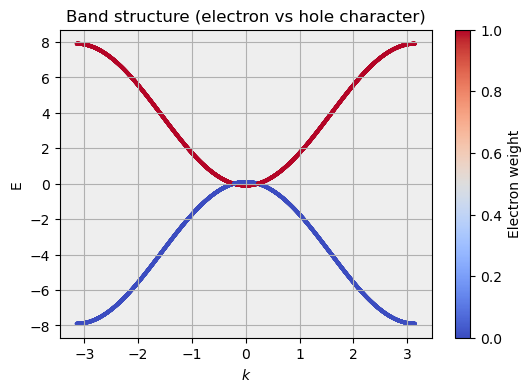

In [25]:
#右边能带
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [s0, np.zeros((2,2))],
    [np.zeros((2,2)), 1*s0]
])

ks = np.linspace(-np.pi, np.pi, 3001)
def Hk(k, H, T):
    return H + T * np.exp(-1j*k) + T.conj().T * np.exp(1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_r, T_r)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-2,2)

#if save:
#    save_fig_by_title(f"4R_quan")   
#plt.show()
if 3==2:
    plt.figure(figsize=(6,4))
    ax = plt.gca()
    ax.set_facecolor('#eeeeee')

    norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    for n in range(energies.shape[1]):
        plt.scatter(
            ks,
            energies[:, n],
            c=spin_expect[:, n],
            cmap='bwr',
            norm=norm_s,
            s=3
        )

    plt.colorbar(label=r'$\langle S_z \rangle$')
    plt.xlabel(r'$k$')
    plt.ylabel('E')
    plt.title('Band structure (spin polarization)')
    plt.grid(True)
    plt.ylim(-delta*4,delta*4)
    plt.xlim(-1,1)
    #plt.xlim(-dela,dela)  
    plt.show()



In [ ]:
#function
#T_l不可逆
def gr_L(T_l, A_l, tol=1e-8):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    # N 就是 yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 对于你来说，这里应该是 4 * xshumu
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r,Sigma_R, Sigma_L

#新函数
def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    N = yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里是 4 * xshumu = 160
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    
    # 构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法直接计算非对角块 G_RL
    # ==========================================
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

固定 Bz = 0.05, 开始使用 RGF 算法扫描能量 E 并计算电导...


Calculating Conductance vs Energy:   0%|          | 0/301 [00:00<?, ?it/s]

Calculating Conductance vs Energy: 100%|██████████| 301/301 [00:16<00:00, 18.16it/s]


已保存图片: D:\结果\2026.4.18\GleiN=2_m=-0.5_A=1_B=0.5_del=0_x=10_uS=0_Ex=0_Bz=0.05.png


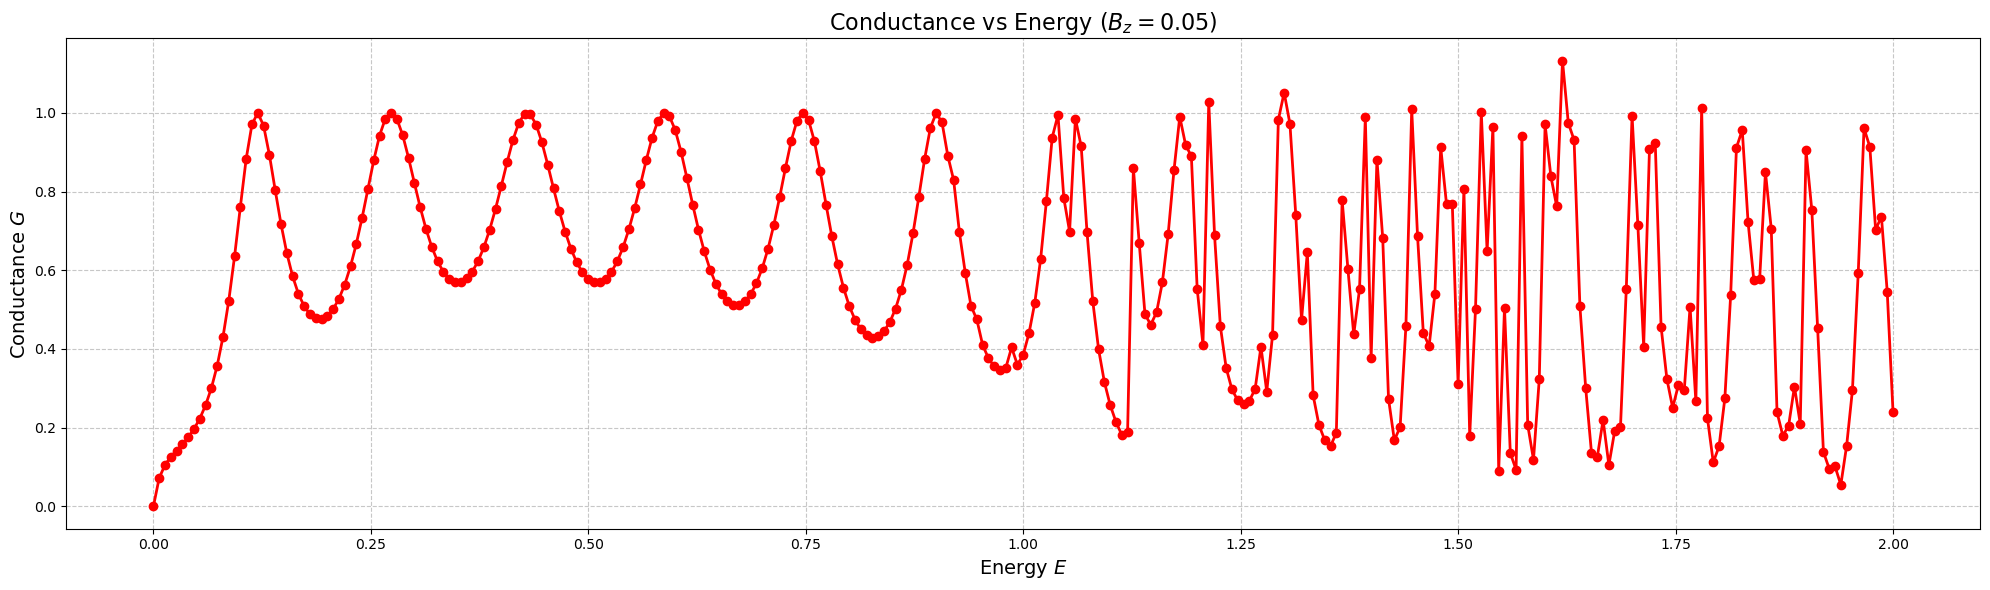

In [18]:
#设定固定的 Bz 和要扫描的能量 E 范围
Bz = 0.05 #0.05
E_values = np.linspace(0, 2, 301)  
G_values = []
eta = 1e-6

print(f"固定 Bz = {Bz}, 开始使用 RGF 算法扫描能量 E 并计算电导...")


H_q_list = []
for i in range(yshumu):

    H_q_i = H_onstie(m, B, a, uS_set, Delta, 0, xshumu, 4, A, Bz, i)
    H_q_list.append(H_q_i)
#H_r = H_onstie(m, B, a, uS_set, 0, 0, xshumu, 4, A, Bz, yshumu) 


for E in tqdm(E_values, desc="Calculating Conductance vs Energy"):
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)

    G_values.append(G_real)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(20, 6))
plt.plot(E_values, G_values, marker='o', linestyle='-', color='r', linewidth=2, markersize=6)

plt.xlabel(r'Energy $E$', fontsize=14)
plt.ylabel(r'Conductance $G$', fontsize=14)
plt.title(rf'Conductance vs Energy ($B_z = {Bz}$)', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

params_str_1 = f"leiN={leiN}_m={m}_A={A}_B={B}_del={delta}_x={xshumu}_uS={uS}_Ex={Ex}_Bz={Bz}"
save_fig_by_title_1('G'+params_str_1)
# 显示图像
plt.show()

开始使用 RGF 算法扫描 Bz 并计算电导...


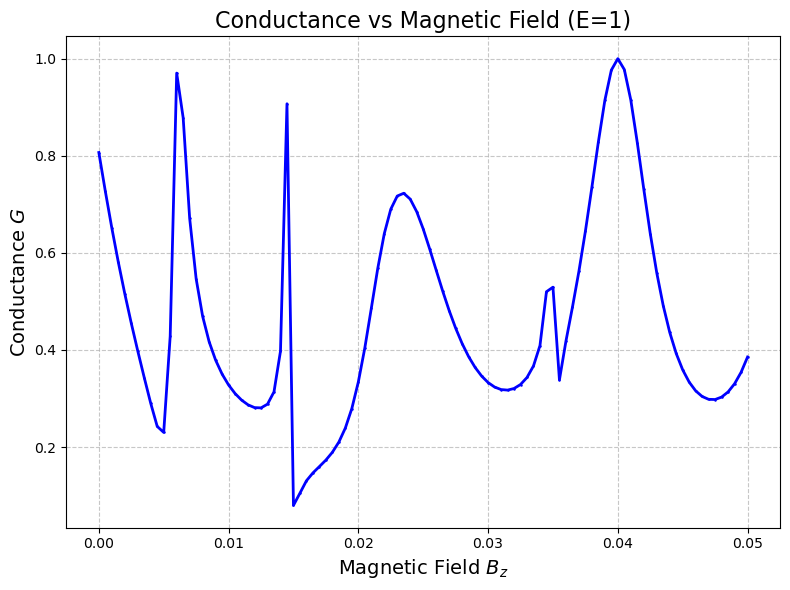

In [30]:
# 设定固定的 E 和要扫描的Bz 范围
Bz_values = np.linspace(0, 0.05, 101)
G_values = []

E = 1
eta = 1e-6

print("开始使用 RGF 算法扫描 Bz 并计算电导...")

for Bz_1 in Bz_values:
    # 1. 根据当前的 Bz 重新生成中间区的哈密顿量列表 H_q_list
    H_q_list = []
    for i in range(yshumu):
        # 这里的 i 就是 yweizhi
        H_q_i = H_onstie(m, B, a, uS_set, Delta, 0, xshumu, 4, A, Bz_1, i)
        H_q_list.append(H_q_i)

    #H_r = H_onstie(m, B, a, uS_set, 0, 0, xshumu, 4, A, Bz_1, yshumu) 
    #H_r = H_onstie(m, B, a, uS_set, 0, 0, xshumu, 4, A, Bz_1, 0) 
        
    # 2. 调用新版 RGF 格林函数计算模块！
    # 注意：现在的 Gr_DD 直接返回的就是 160x160 的非对角透射矩阵 G_RL
    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    # 3. 计算单层的展宽矩阵 (维度: 160 x 160)
    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    # 4. 直接计算电导 (全是 160x160 的小矩阵相乘，速度起飞)
    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    # 记录数据点并打印进度
    G_values.append(G_real)
    #print(f"Bz = {Bz:.3f}, 电导 G = {G_real:.6e}")
# ----------------- 画图部分 -----------------
plt.figure(figsize=(8, 6))
plt.plot(Bz_values, G_values, marker='o', linestyle='-', color='b', linewidth=2, markersize=0.8)

# 设置坐标轴标签和标题
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G$', fontsize=14)
plt.title(fr'Conductance vs Magnetic Field (E={E})', fontsize=16)

# 设置网格和排版
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 如果你需要自动保存图片，取消下面两行的注释并确保你之前定义了 save_dir
# filename = os.path.join(save_dir, "G_vs_Bz_RGF.png")
# plt.savefig(filename, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()
